<a href="https://colab.research.google.com/github/anshpatel-177/Customer-Segmentation/blob/main/Customer_Segmentation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING

# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# 2. LOAD DATASET


df = pd.read_csv("/content/customer_segmentation.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


print("\nDataset Information:")
print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nStatistical Summary:")
print(df.describe())



Dataset loaded successfully!
Shape of dataset: (2240, 29)

First 5 rows:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCm

In [4]:
# 4. CHECK MISSING VALUES

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:",
      df.isnull().sum().sum())



Missing Values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Total Missing Values: 24


In [6]:
 #5. HANDLE MISSING VALUES

# Income has missing values.
# Fill missing Income values with median.

df['Income'] = df['Income'].fillna(df['Income'].median())

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

# 6. CHECK DUPLICATE VALUES

print("\nNumber of duplicate rows:",
      df.duplicated().sum())


# Remove duplicates if present
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:",
      df.shape)


Missing values after cleaning:
0

Number of duplicate rows: 0
Dataset shape after removing duplicates: (2240, 29)



Data Types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object


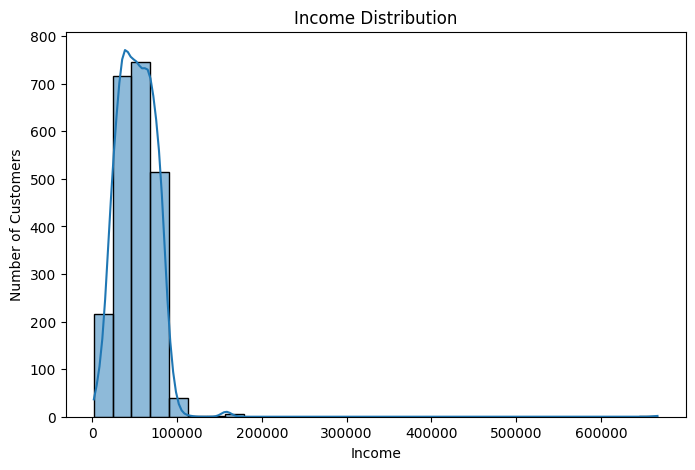


Total Spending created.


In [7]:
# 7. CHECK DATA TYPES

print("\nData Types:")
print(df.dtypes)

# 8. BASIC EDA

# Distribution of Income

plt.figure(figsize=(8,5))

sns.histplot(
    df['Income'],
    bins=30,
    kde=True
)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.show()


# 9. TOTAL SPENDING FEATURE

df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

print("\nTotal Spending created.")



In [8]:
# 10. TOTAL PURCHASES FEATURE

df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

print("Total Purchases created.")


# 11. TOTAL CHILDREN FEATURE

df['Total_Children'] = (
    df['Kidhome'] +
    df['Teenhome']
)

print("Total Children created.")


Total Purchases created.
Total Children created.


In [9]:
# 12. TOTAL CAMPAIGN ACCEPTANCE

df['Total_Campaigns'] = (
    df['AcceptedCmp1'] +
    df['AcceptedCmp2'] +
    df['AcceptedCmp3'] +
    df['AcceptedCmp4'] +
    df['AcceptedCmp5']
)

print("Total Campaigns created.")


# 13. DISPLAY NEW FEATURES

print("\nNew Features:")
print(
    df[
        [
            'Income',
            'Total_Spending',
            'Total_Purchases',
            'Total_Children',
            'Total_Campaigns'
        ]
    ].head()
)


Total Campaigns created.

New Features:
    Income  Total_Spending  Total_Purchases  Total_Children  Total_Campaigns
0  58138.0            1617               22               0                0
1  46344.0              27                4               2                0
2  71613.0             776               20               0                0
3  26646.0              53                6               1                0
4  58293.0             422               14               1                0


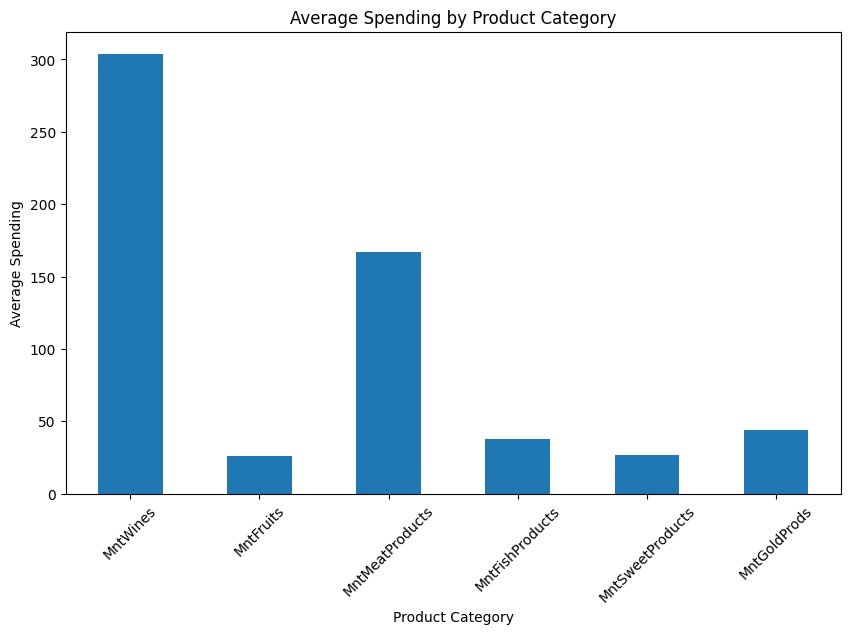

In [10]:
# 14. CUSTOMER SPENDING ANALYSIS

spending_columns = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

average_spending = df[spending_columns].mean()

plt.figure(figsize=(10,6))

average_spending.plot(kind='bar')

plt.title("Average Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Spending")

plt.xticks(rotation=45)

plt.show()


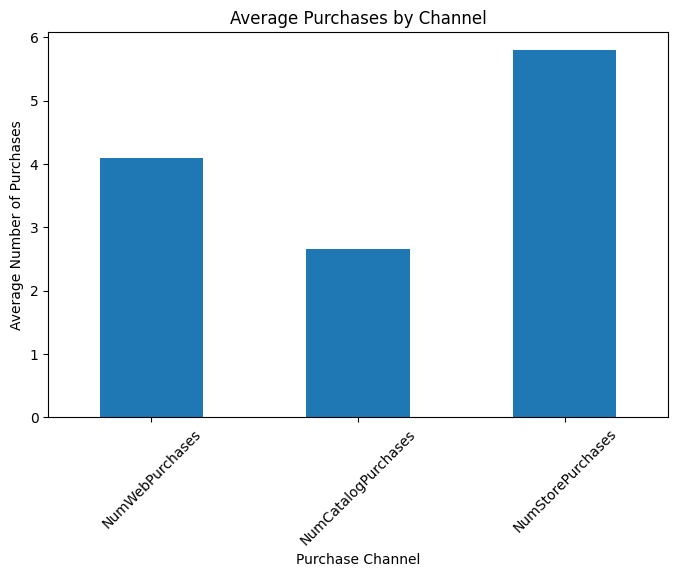

In [11]:
# 15. PURCHASE CHANNEL ANALYSIS

purchase_columns = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

average_purchases = df[purchase_columns].mean()

plt.figure(figsize=(8,5))

average_purchases.plot(kind='bar')

plt.title("Average Purchases by Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Average Number of Purchases")

plt.xticks(rotation=45)

plt.show()


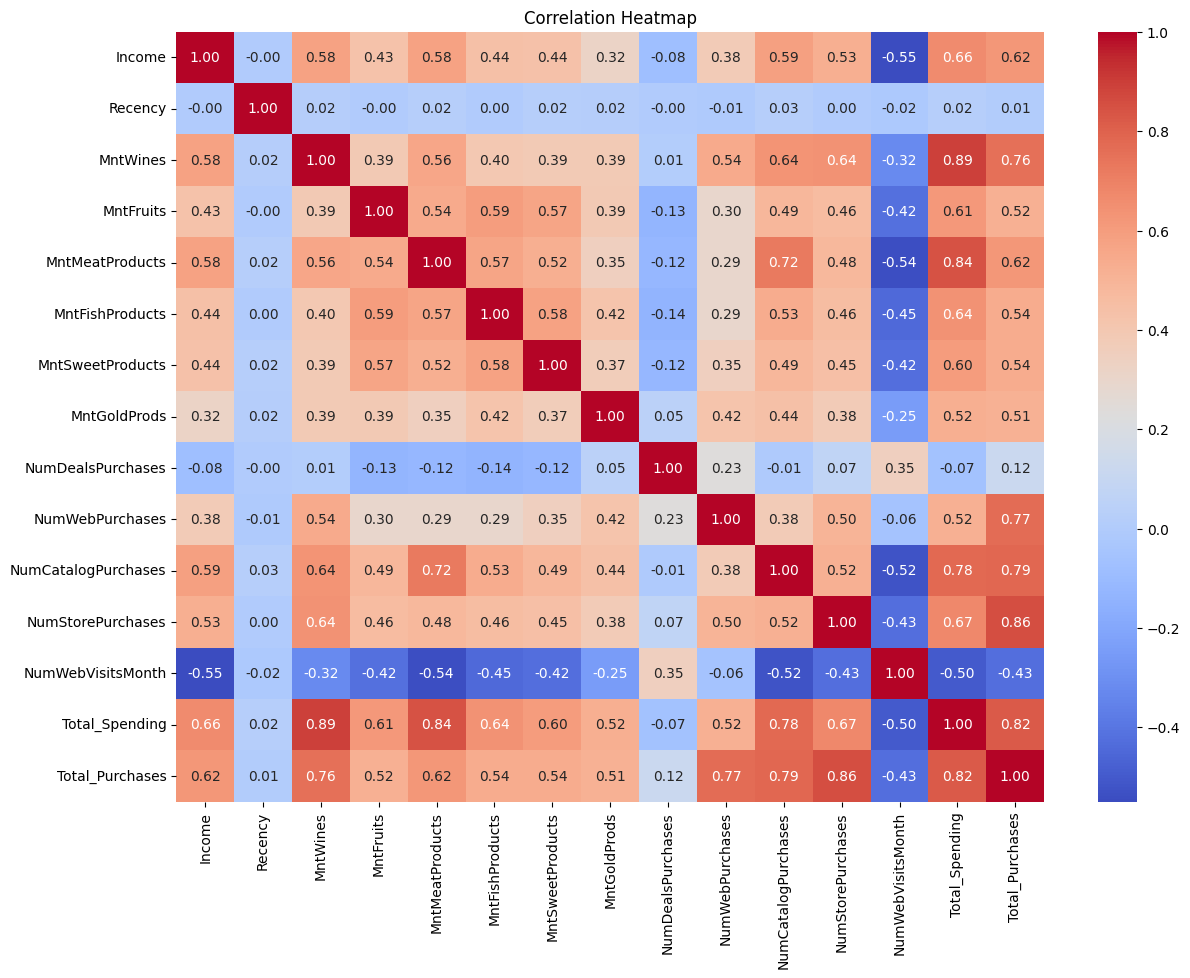

In [12]:
# 16. CORRELATION HEATMAP

correlation_features = [
    'Income',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Total_Spending',
    'Total_Purchases'
]

plt.figure(figsize=(14,10))

sns.heatmap(
    df[correlation_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


In [13]:
# 17. SELECT FEATURES FOR CLUSTERING

features = [
    'Income',
    'Recency',
    'Total_Spending',
    'Total_Purchases',
    'NumDealsPurchases',
    'NumWebVisitsMonth'
]

X = df[features].copy()

print("\nFeatures selected for clustering:")
print(features)

print("\nShape of X:", X.shape)



Features selected for clustering:
['Income', 'Recency', 'Total_Spending', 'Total_Purchases', 'NumDealsPurchases', 'NumWebVisitsMonth']

Shape of X: (2240, 6)


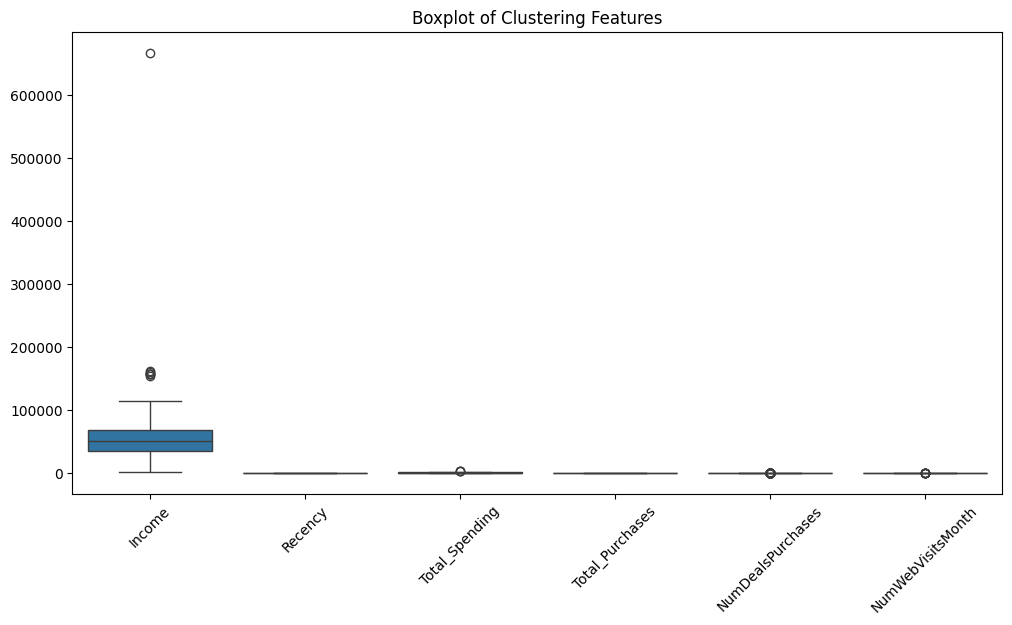


Features standardized successfully.


In [14]:
# 18. CHECK OUTLIERS USING BOXPLOTS

plt.figure(figsize=(12,6))

sns.boxplot(data=X)

plt.title("Boxplot of Clustering Features")

plt.xticks(rotation=45)

plt.show()


# 19. STANDARDIZE FEATURES


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nFeatures standardized successfully.")



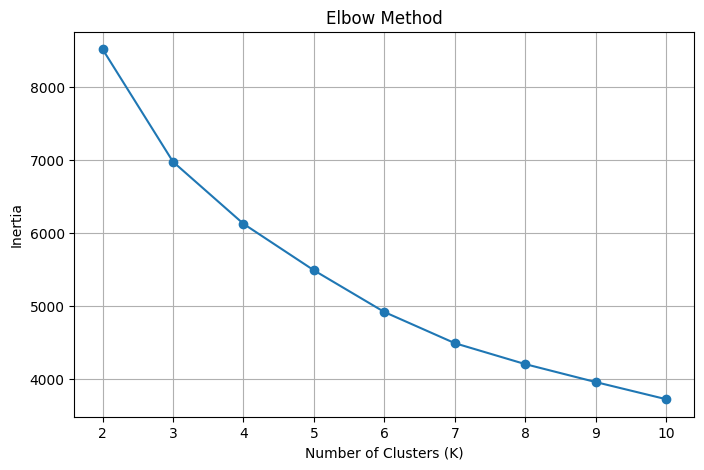

In [15]:
# 20. ELBOW METHOD

inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(K_range)

plt.grid(True)

plt.show()



Silhouette Scores:
K = 2 : Silhouette Score = 0.3598
K = 3 : Silhouette Score = 0.3374
K = 4 : Silhouette Score = 0.2817
K = 5 : Silhouette Score = 0.2480
K = 6 : Silhouette Score = 0.2490
K = 7 : Silhouette Score = 0.2494
K = 8 : Silhouette Score = 0.2460
K = 9 : Silhouette Score = 0.2397
K = 10 : Silhouette Score = 0.2348


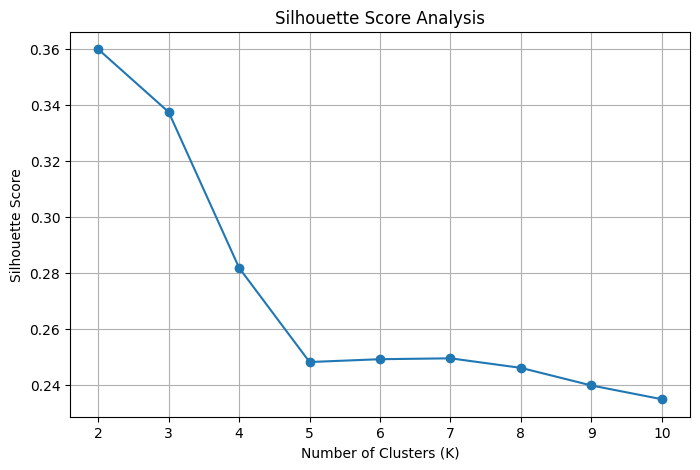


Selected number of clusters: 4


In [16]:
# 21. SILHOUETTE SCORE

silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)


# Display scores

print("\nSilhouette Scores:")

for k, score in zip(K_range, silhouette_scores):

    print(
        f"K = {k} : "
        f"Silhouette Score = {score:.4f}"
    )


# Plot silhouette scores

plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")

plt.xticks(K_range)

plt.grid(True)

plt.show()


# 22. SELECT NUMBER OF CLUSTERS

optimal_k = 4

print("\nSelected number of clusters:", optimal_k)


In [17]:
# 23. APPLY K-MEANS CLUSTERING

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nK-Means clustering completed.")


# 24. CLUSTER DISTRIBUTION

cluster_counts = df['Cluster'].value_counts().sort_index()

print("\nCustomers in each cluster:")
print(cluster_counts)



K-Means clustering completed.

Customers in each cluster:
Cluster
0    331
1    796
2    539
3    574
Name: count, dtype: int64


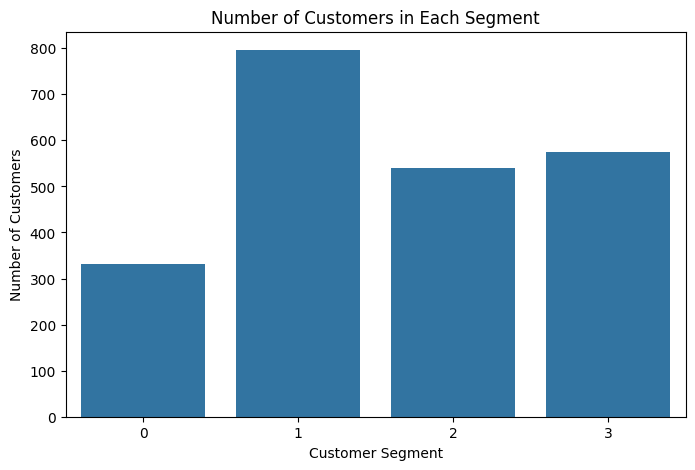

In [18]:
# 25. VISUALIZE CLUSTER DISTRIBUTION

plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=df
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()


In [19]:
# 26. CLUSTER SUMMARY

cluster_summary = df.groupby('Cluster')[features].mean()

print("\nCluster Summary:")
print(cluster_summary.round(2))

# 27. CLUSTER SUMMARY - INCLUDING SPENDING CATEGORIES

detailed_features = [
    'Income',
    'Recency',
    'Total_Spending',
    'Total_Purchases',
    'NumDealsPurchases',
    'NumWebVisitsMonth',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

detailed_summary = df.groupby('Cluster')[detailed_features].mean()

print("\nDetailed Cluster Analysis:")
print(detailed_summary.round(2))



Cluster Summary:
           Income  Recency  Total_Spending  Total_Purchases  \
Cluster                                                       
0        53759.96    48.34          706.76            16.53   
1        74353.54    49.35         1233.53            19.28   
2        36974.17    75.65          132.93             6.68   
3        35024.43    24.29          121.10             6.39   

         NumDealsPurchases  NumWebVisitsMonth  
Cluster                                        
0                     5.75               6.86  
1                     1.45               3.21  
2                     1.95               6.23  
3                     1.92               6.49  

Detailed Cluster Analysis:
           Income  Recency  Total_Spending  Total_Purchases  \
Cluster                                                       
0        53759.96    48.34          706.76            16.53   
1        74353.54    49.35         1233.53            19.28   
2        36974.17    75.65         

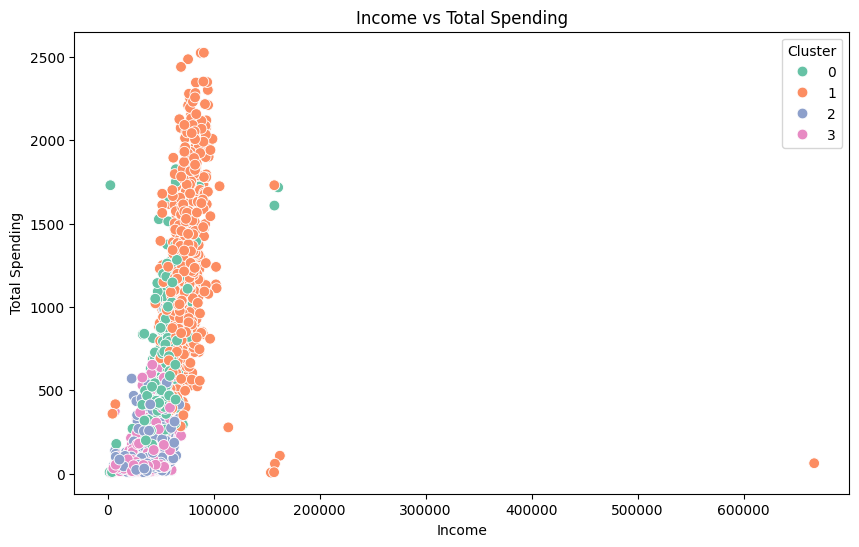

In [20]:
# 28. INCOME VS TOTAL SPENDING

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending',
    hue='Cluster',
    palette='Set2',
    s=60
)

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.legend(title="Cluster")

plt.show()

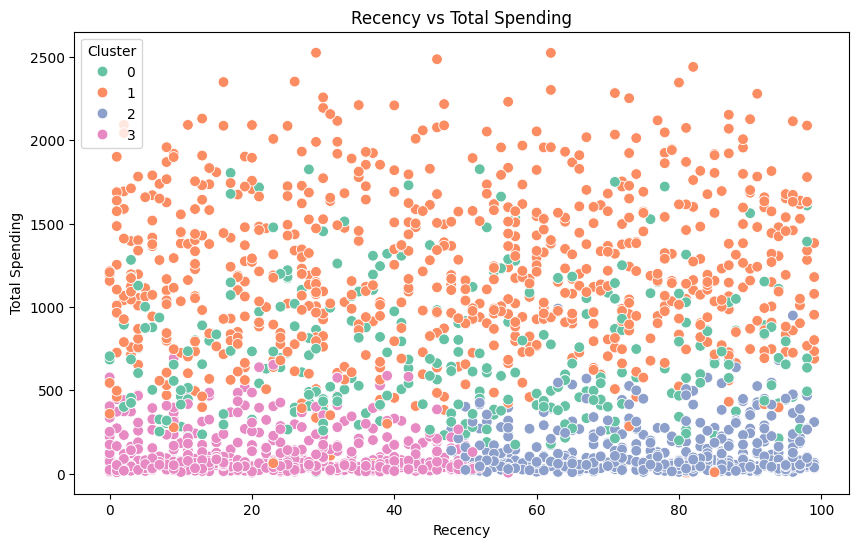

In [21]:
# 29. RECENCY VS TOTAL SPENDING

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Recency',
    y='Total_Spending',
    hue='Cluster',
    palette='Set2',
    s=60
)

plt.title("Recency vs Total Spending")
plt.xlabel("Recency")
plt.ylabel("Total Spending")

plt.legend(title="Cluster")

plt.show()


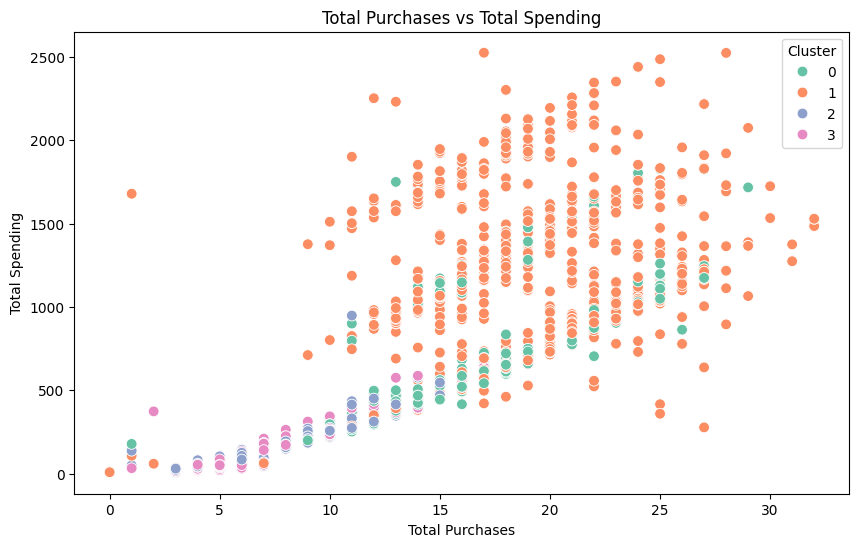

In [22]:
# 30. TOTAL PURCHASES VS TOTAL SPENDING

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Total_Purchases',
    y='Total_Spending',
    hue='Cluster',
    palette='Set2',
    s=60
)

plt.title("Total Purchases vs Total Spending")
plt.xlabel("Total Purchases")
plt.ylabel("Total Spending")

plt.legend(title="Cluster")

plt.show()


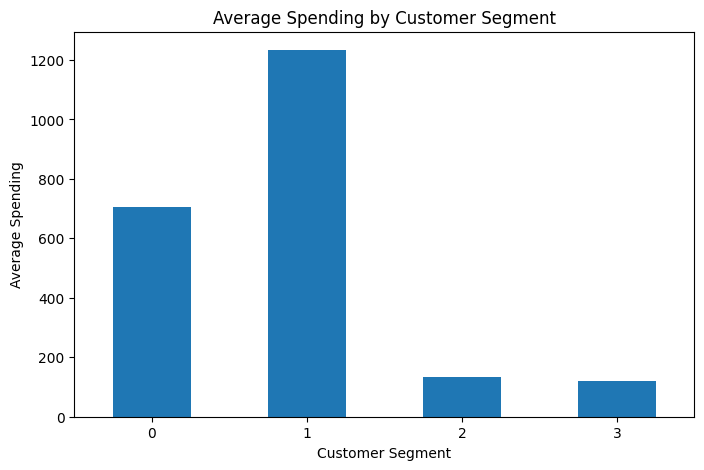

In [23]:
# 31. CLUSTER SPENDING COMPARISON

cluster_spending = df.groupby('Cluster')[
    'Total_Spending'
].mean()

plt.figure(figsize=(8,5))

cluster_spending.plot(
    kind='bar'
)

plt.title("Average Spending by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Spending")

plt.xticks(rotation=0)

plt.show()


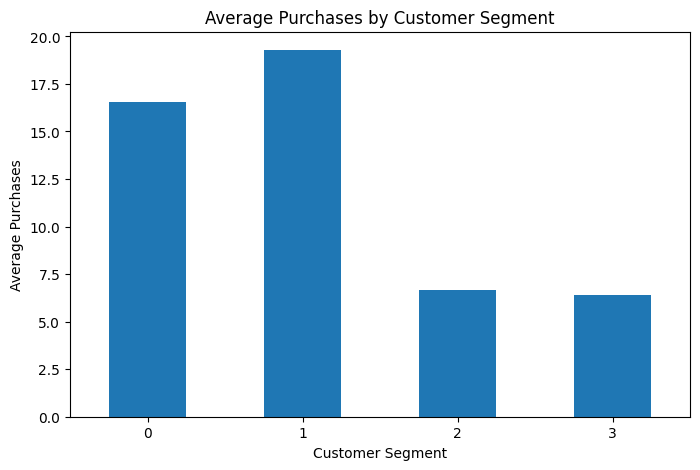

In [24]:
# 32. CLUSTER PURCHASE COMPARISON

cluster_purchase = df.groupby('Cluster')[
    'Total_Purchases'
].mean()

plt.figure(figsize=(8,5))

cluster_purchase.plot(
    kind='bar'
)

plt.title("Average Purchases by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Purchases")

plt.xticks(rotation=0)

plt.show()


In [26]:
# 33. PCA FOR 2D VISUALIZATION

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = df['Cluster'].values


print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal variance explained:",
    pca.explained_variance_ratio_.sum()
)


Explained variance ratio:
[0.4706414  0.19879113]

Total variance explained: 0.6694325339414247


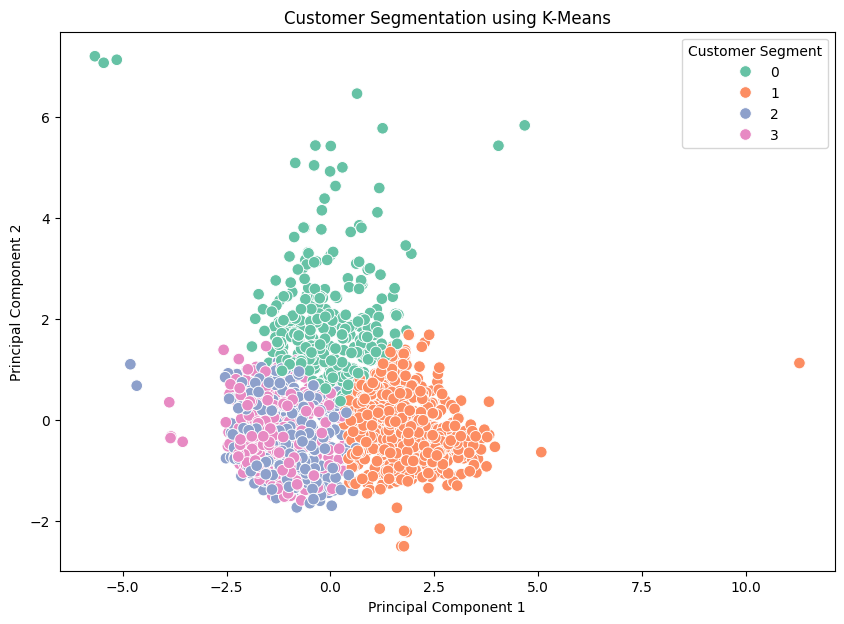

In [27]:
# 34. PCA CLUSTER VISUALIZATION

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',
    s=70
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Customer Segment")

plt.show()


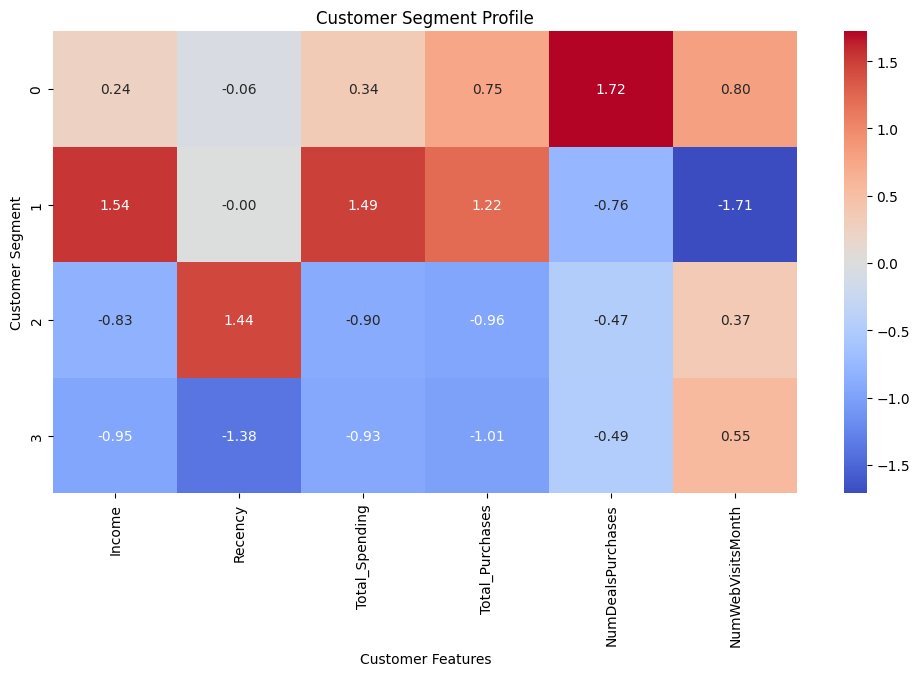

In [28]:
# 35. RADAR-STYLE CLUSTER COMPARISON

# Normalize cluster averages for easier comparison

cluster_profile = df.groupby('Cluster')[
    features
].mean()

cluster_profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile),
    columns=features,
    index=cluster_profile.index
)

plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title("Customer Segment Profile")

plt.xlabel("Customer Features")
plt.ylabel("Customer Segment")

plt.show()

In [29]:
# 36. CUSTOMER SEGMENT PROFILE

print("\n==============================")
print("CUSTOMER SEGMENT PROFILES")
print("==============================")

for cluster in sorted(df['Cluster'].unique()):

    cluster_data = df[df['Cluster'] == cluster]

    print(f"\nCluster {cluster}")
    print("------------------------------")

    print(
        "Number of Customers:",
        len(cluster_data)
    )

    print(
        "Average Income:",
        round(cluster_data['Income'].mean(), 2)
    )

    print(
        "Average Spending:",
        round(cluster_data['Total_Spending'].mean(), 2)
    )

    print(
        "Average Purchases:",
        round(cluster_data['Total_Purchases'].mean(), 2)
    )

    print(
        "Average Recency:",
        round(cluster_data['Recency'].mean(), 2)
    )

    print(
        "Average Deal Purchases:",
        round(cluster_data['NumDealsPurchases'].mean(), 2)
    )

    print(
        "Average Web Visits:",
        round(cluster_data['NumWebVisitsMonth'].mean(), 2)
    )


CUSTOMER SEGMENT PROFILES

Cluster 0
------------------------------
Number of Customers: 331
Average Income: 53759.96
Average Spending: 706.76
Average Purchases: 16.53
Average Recency: 48.34
Average Deal Purchases: 5.75
Average Web Visits: 6.86

Cluster 1
------------------------------
Number of Customers: 796
Average Income: 74353.54
Average Spending: 1233.53
Average Purchases: 19.28
Average Recency: 49.35
Average Deal Purchases: 1.45
Average Web Visits: 3.21

Cluster 2
------------------------------
Number of Customers: 539
Average Income: 36974.17
Average Spending: 132.93
Average Purchases: 6.68
Average Recency: 75.65
Average Deal Purchases: 1.95
Average Web Visits: 6.23

Cluster 3
------------------------------
Number of Customers: 574
Average Income: 35024.43
Average Spending: 121.1
Average Purchases: 6.39
Average Recency: 24.29
Average Deal Purchases: 1.92
Average Web Visits: 6.49


In [30]:
# 37. AUTOMATIC BASIC SEGMENT DESCRIPTION

print("\n==============================")
print("SEGMENT INTERPRETATION")
print("==============================")

for cluster in sorted(df['Cluster'].unique()):

    cluster_data = df[df['Cluster'] == cluster]

    avg_spending = cluster_data['Total_Spending'].mean()
    avg_income = cluster_data['Income'].mean()
    avg_purchases = cluster_data['Total_Purchases'].mean()
    avg_recency = cluster_data['Recency'].mean()

    print(f"\nCluster {cluster}:")

    if avg_spending > df['Total_Spending'].mean():
        print("- Spending: HIGH")
    else:
        print("- Spending: LOW/MEDIUM")

    if avg_income > df['Income'].mean():
        print("- Income: HIGH")
    else:
        print("- Income: LOW/MEDIUM")

    if avg_purchases > df['Total_Purchases'].mean():
        print("- Purchase Frequency: HIGH")
    else:
        print("- Purchase Frequency: LOW/MEDIUM")

    if avg_recency < df['Recency'].mean():
        print("- Recent Activity: HIGHER")
    else:
        print("- Recent Activity: LOWER")




SEGMENT INTERPRETATION

Cluster 0:
- Spending: HIGH
- Income: HIGH
- Purchase Frequency: HIGH
- Recent Activity: HIGHER

Cluster 1:
- Spending: HIGH
- Income: HIGH
- Purchase Frequency: HIGH
- Recent Activity: LOWER

Cluster 2:
- Spending: LOW/MEDIUM
- Income: LOW/MEDIUM
- Purchase Frequency: LOW/MEDIUM
- Recent Activity: LOWER

Cluster 3:
- Spending: LOW/MEDIUM
- Income: LOW/MEDIUM
- Purchase Frequency: LOW/MEDIUM
- Recent Activity: HIGHER


In [31]:
# 38. FIND HIGHEST VALUE CUSTOMER SEGMENT

highest_spending_cluster = (
    df.groupby('Cluster')['Total_Spending']
    .mean()
    .idxmax()
)

highest_spending_value = (
    df.groupby('Cluster')['Total_Spending']
    .mean()
    .max()
)

print(
    "\nCluster with highest average spending:",
    highest_spending_cluster
)

print(
    "Average spending:",
    round(highest_spending_value, 2)
)


Cluster with highest average spending: 1
Average spending: 1233.53


In [32]:
# 39. FIND MOST ACTIVE CUSTOMER SEGMENT

most_active_cluster = (
    df.groupby('Cluster')['Total_Purchases']
    .mean()
    .idxmax()
)

print(
    "\nCluster with highest purchase frequency:",
    most_active_cluster
)


Cluster with highest purchase frequency: 1


In [33]:
# 40. FIND MOST DEAL-ORIENTED SEGMENT\

deal_cluster = (
    df.groupby('Cluster')['NumDealsPurchases']
    .mean()
    .idxmax()
)

print(
    "\nMost deal-oriented cluster:",
    deal_cluster
)



Most deal-oriented cluster: 0


In [34]:
# 41. SAVE CLUSTERED DATASET

df.to_csv(
    "customer_segmentation_with_clusters.csv",
    index=False
)

print(
    "\nFinal clustered dataset saved as:"
)

print(
    "customer_segmentation_with_clusters.csv"
)



Final clustered dataset saved as:
customer_segmentation_with_clusters.csv


In [35]:
# 42. FINAL DATASET PREVIEW

print("\nFinal Dataset:")
print(df.head())

# 43. FINAL PROJECT SUMMARY

print("\n==============================================")
print("CUSTOMER SEGMENTATION PROJECT COMPLETED")
print("==============================================")

print("Total Customers:", len(df))
print("Total Features:", len(df.columns))
print("Number of Clusters:", optimal_k)

print("\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

print("\nProject successfully completed!")


Final Dataset:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  AcceptedCmp2  Complain  Z_CostContact  \
0  04-09-2012       58       635  ...             0         0              3   
1  08-03-2014       38        11  ...             0         0              3   
2  21-08-2013       26       426  ...             0         0              3   
3  10-02-2014       26        11  ...             0         0              3   
4  19-01-2014       94       173  ...             0         0              3   

   Z_Revenue  Response  Total_Spen